# Lab Segmentation 1

In [17]:
from commonfunctions import *
%matplotlib inline
import skimage.io as io
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


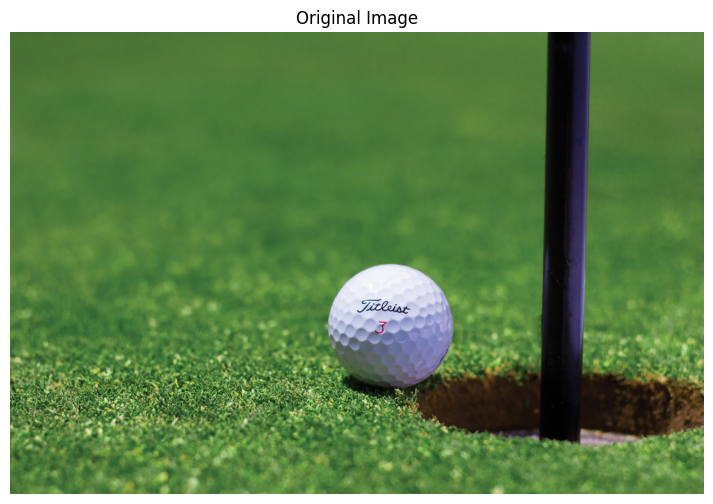

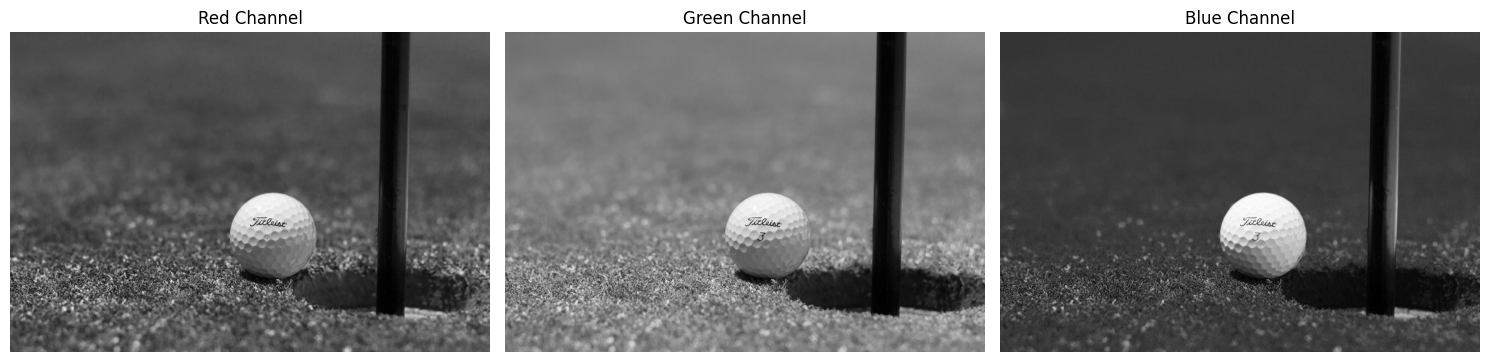

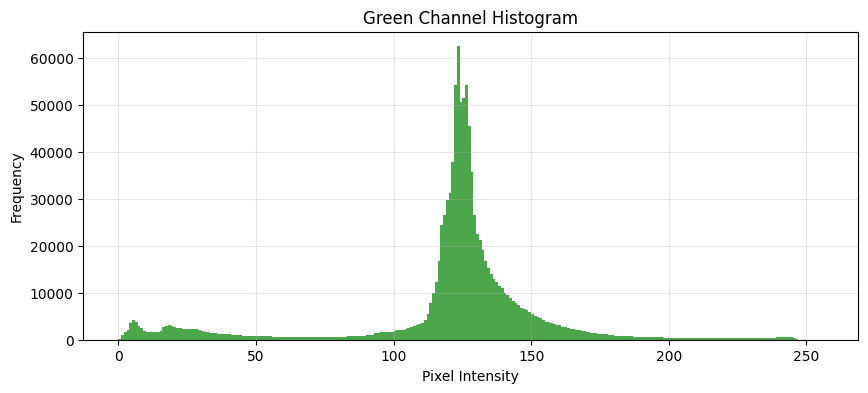

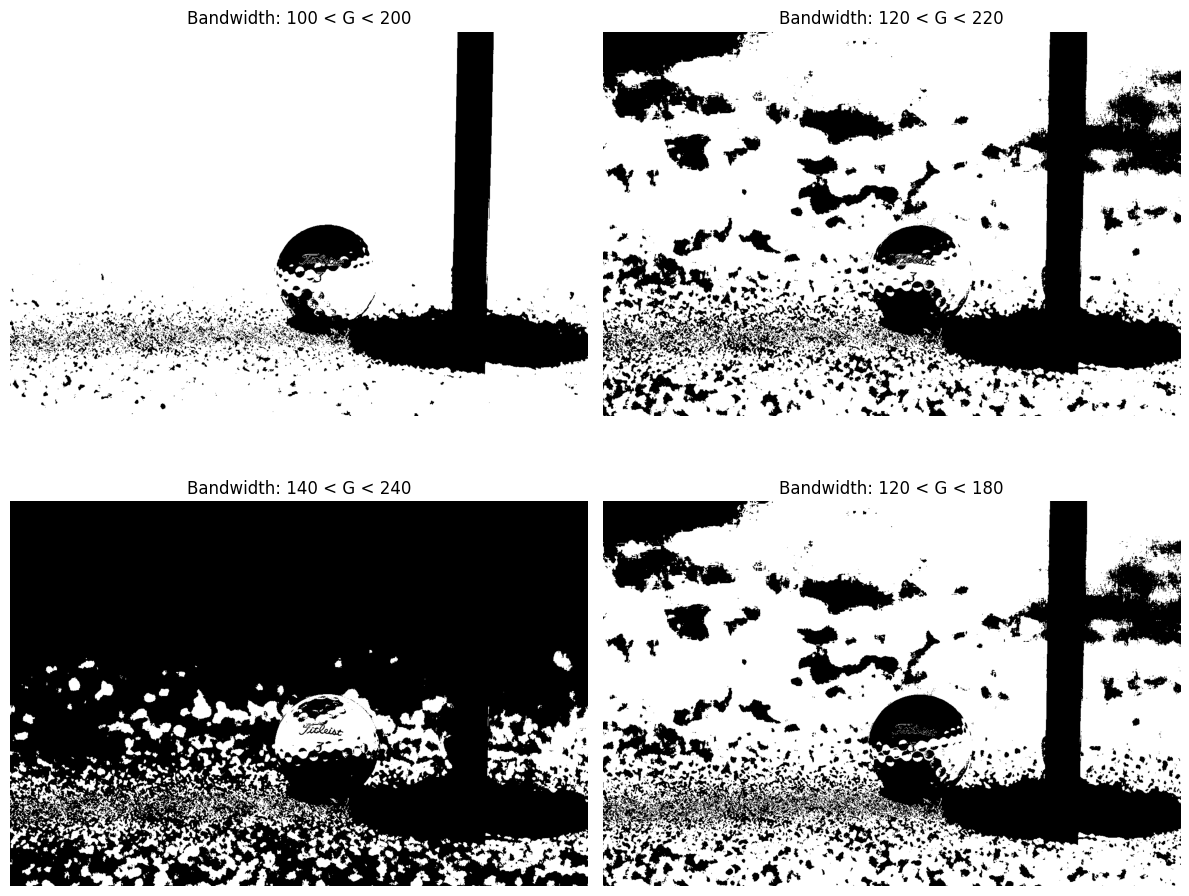

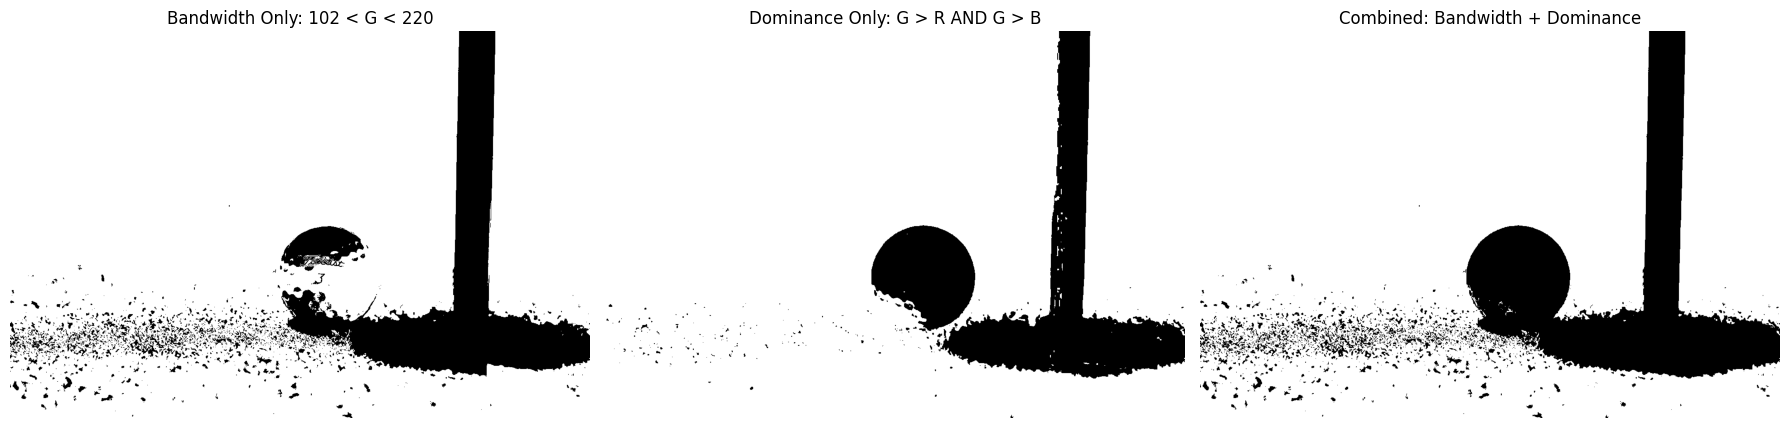

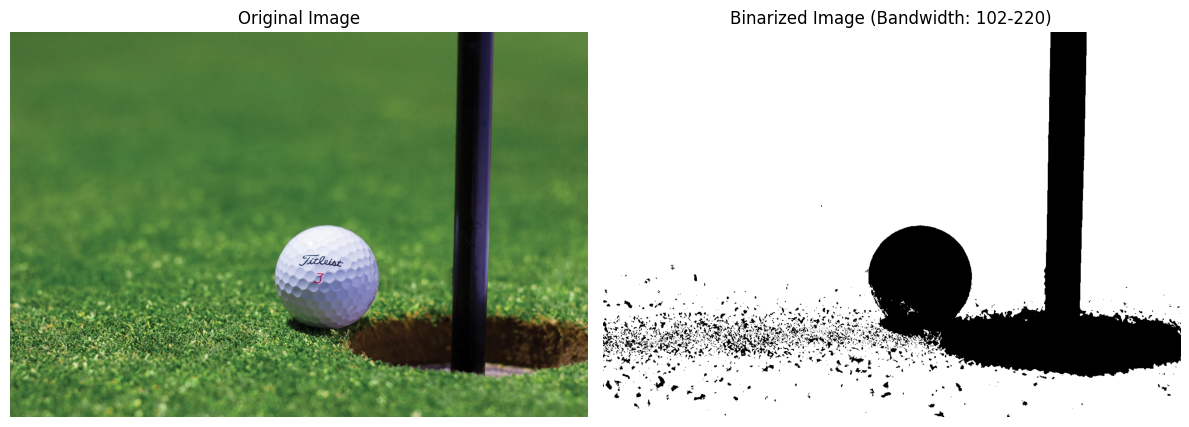

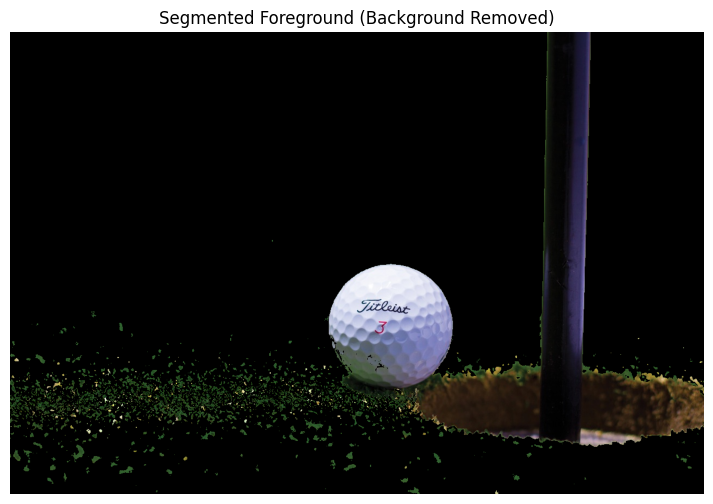

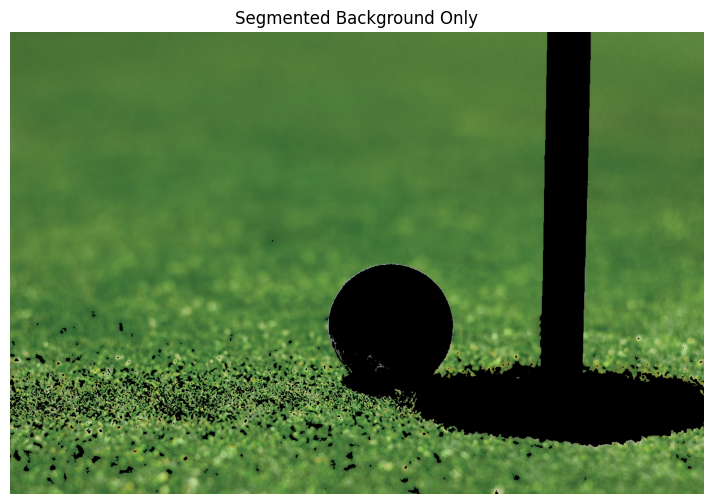

In [76]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

## For all requirements: The quality of the results is evaluated.

# 1- Read the image 
# [VERY IMPORTANT] and convert it to float: image = image.astype(float)
# read image golf
image = io.imread('imgs/exp1/golf.jpeg')
image = image.astype(float)

# Display original image
plt.figure(figsize=(10, 6))
plt.imshow(image.astype(np.uint8))
plt.title('Original Image')
plt.axis('off')
plt.show()

# 2- Retrieve the 3 channels of the image(R,G,B) (will be used in the coming steps)
R = image[:, :, 0]
G = image[:, :, 1]
B = image[:, :, 2]

# Display each channel
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(R, cmap='gray')
axes[0].set_title('Red Channel')
axes[0].axis('off')

axes[1].imshow(G, cmap='gray')
axes[1].set_title('Green Channel')
axes[1].axis('off')

axes[2].imshow(B, cmap='gray')
axes[2].set_title('Blue Channel')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 3- Visually (not by code) detect the dominating color channel (C) for the background (R, G or B)
# ANSWER: Looking at the three channels, the GREEN channel appears to be the dominating channel
# for the background (grass/field area), showing the brightest/highest values in the background region.

# 4- Draw the dominating channel (r, g or b) thresholded by BANDWIDTH threshold
# Bandwidth thresholding: lower_threshold < pixel_value < upper_threshold

# Let's analyze the green channel histogram first
plt.figure(figsize=(10, 4))
plt.hist(G.ravel(), bins=256, range=(0, 256), color='green', alpha=0.7)
plt.title('Green Channel Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

# Try different bandwidth ranges
bandwidth_ranges = [
    (100, 200),
    (120, 220),
    (140, 240),
    (120, 180)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for idx, (lower, upper) in enumerate(bandwidth_ranges):
    thresholded = (G > lower) & (G < upper)
    axes[idx].imshow(thresholded, cmap='gray')
    axes[idx].set_title(f'Bandwidth: {lower} < G < {upper}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# 5- Get an intuitive way to make a mask using bandwidth thresholding
# Combined approach: Use bandwidth on green + green dominance condition

# Choose optimal bandwidth
lower_threshold = 102
upper_threshold = 220

# Bandwidth mask: pixels where green is in the specified range
bandwidth_mask = (G > lower_threshold) & (G < upper_threshold)

# Combined mask: Bandwidth + Green dominates other channels
combined_mask = bandwidth_mask & (G > R) & (G > B)

# Display comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(bandwidth_mask, cmap='gray')
axes[0].set_title(f'Bandwidth Only: {lower_threshold} < G < {upper_threshold}')
axes[0].axis('off')

axes[1].imshow((G > R) & (G > B), cmap='gray')
axes[1].set_title('Dominance Only: G > R AND G > B')
axes[1].axis('off')

axes[2].imshow(combined_mask, cmap='gray')
axes[2].set_title('Combined: Bandwidth + Dominance')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 6- Display the binarized image
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image.astype(np.uint8))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(combined_mask, cmap='gray')
plt.title(f'Binarized Image (Bandwidth: {lower_threshold}-{upper_threshold})')
plt.axis('off')

plt.tight_layout()
plt.show()

# Show the segmented foreground
foreground = image.copy()
foreground[combined_mask] = 0  # Set background pixels to black

plt.figure(figsize=(10, 6))
plt.imshow(foreground.astype(np.uint8))
plt.title('Segmented Foreground (Background Removed)')
plt.axis('off')
plt.show()

# Alternative: Show only the background
background = image.copy()
background[~combined_mask] = 0  # Set foreground pixels to black

plt.figure(figsize=(10, 6))
plt.imshow(background.astype(np.uint8))
plt.title('Segmented Background Only')
plt.axis('off')
plt.show()

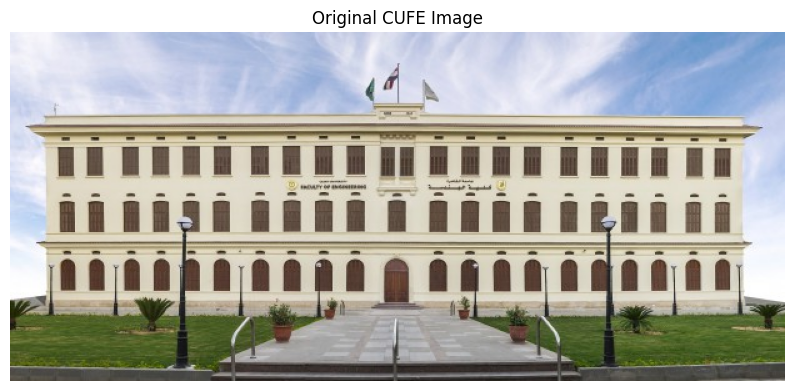

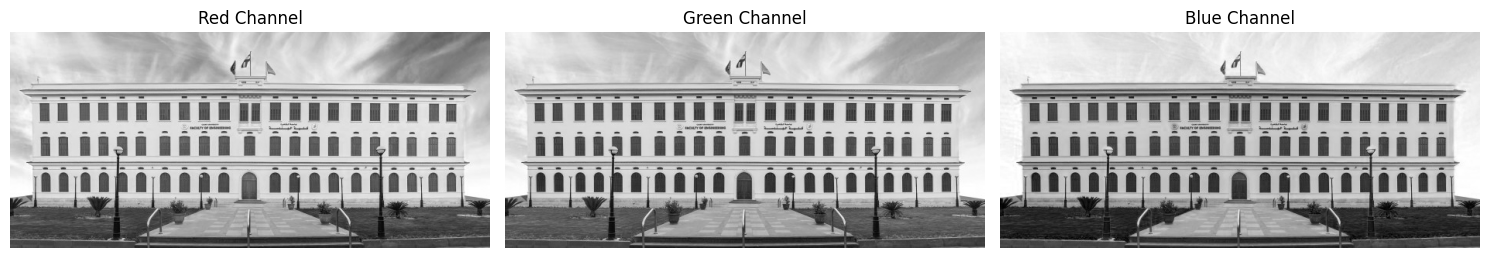

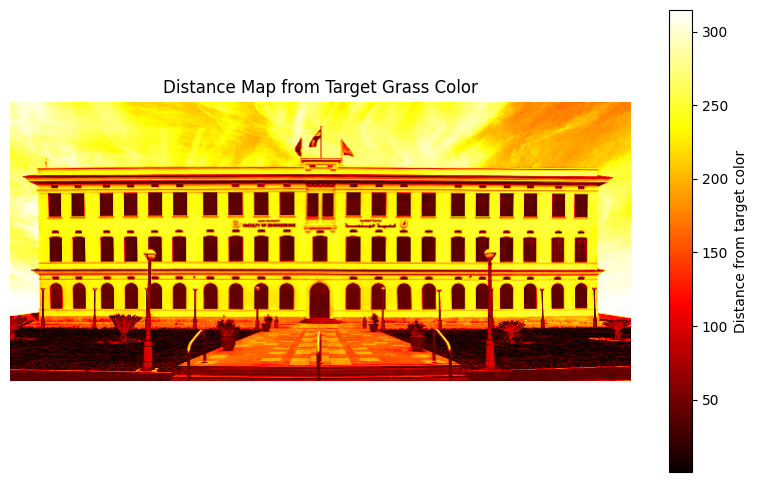

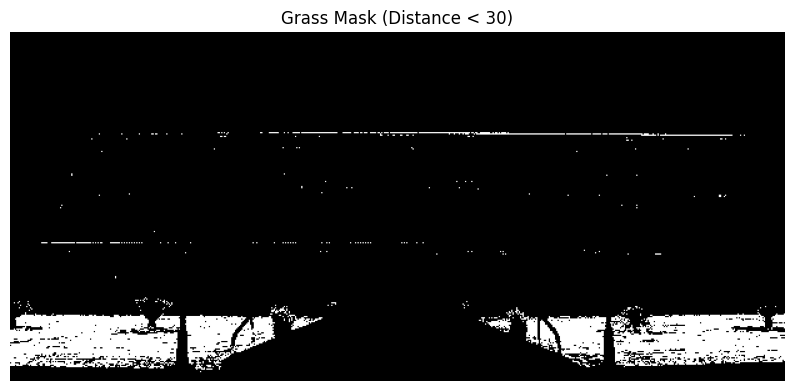

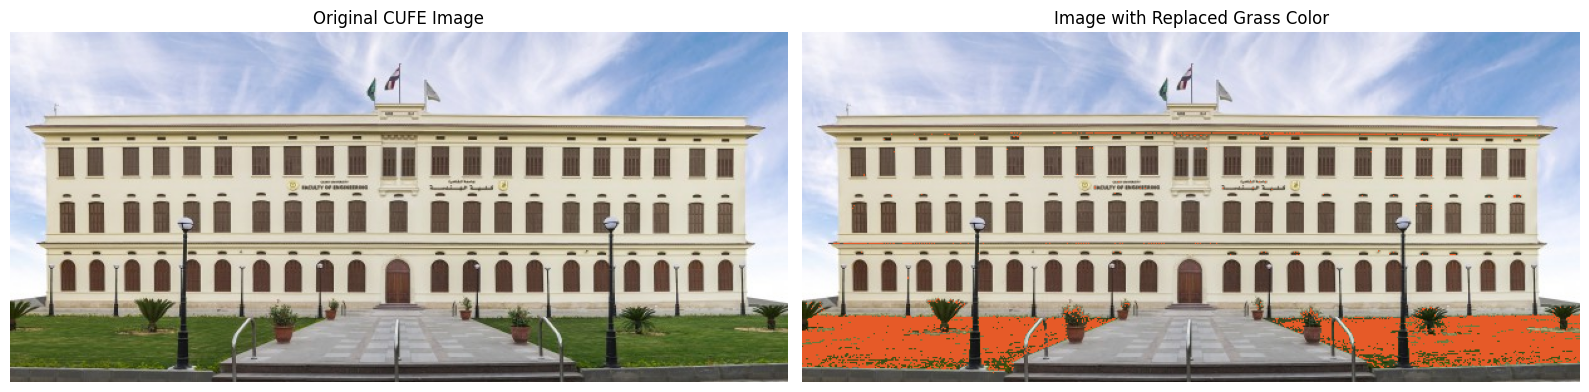

Modified image saved as 'imgs/exp2/cufe_modified.png'


In [82]:
# Experiment 2: Color Replacement
# Replace grass color in CUFE image with a target color

# 1- Get the required RGB color (Using a color picker)
# For grass in the CUFE image, typical green values are around:
# You can adjust these values based on visual inspection
target_grass_color = np.array([80, 102, 43])  # RGB values of grass to find

# 2- Read image
cufe_image = io.imread('imgs/exp2/cufe.png')
cufe_image = cufe_image.astype(float)

# Display original image
plt.figure(figsize=(10, 6))
plt.imshow(cufe_image.astype(np.uint8))
plt.title('Original CUFE Image')
plt.axis('off')
plt.show()

# 3- extract R, G and B channels (as float)
R_cufe = cufe_image[:, :, 0]
G_cufe = cufe_image[:, :, 1]
B_cufe = cufe_image[:, :, 2]

# Display each channel
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(R_cufe, cmap='gray')
axes[0].set_title('Red Channel')
axes[0].axis('off')

axes[1].imshow(G_cufe, cmap='gray')
axes[1].set_title('Green Channel')
axes[1].axis('off')

axes[2].imshow(B_cufe, cmap='gray')
axes[2].set_title('Blue Channel')
axes[2].axis('off')
plt.tight_layout()
plt.show()

# 4- calculate differences FOR EACH CHANNEL (between the image and the required pixel value)
diff_R = R_cufe - target_grass_color[0]
diff_G = G_cufe - target_grass_color[1]
diff_B = B_cufe - target_grass_color[2]

# 5- calculate overall distance from the given RGB color 
# Using Euclidean distance (take care of the minus distances by squaring)
distance = np.sqrt(diff_R**2 + diff_G**2 + diff_B**2)

# Visualize the distance map
plt.figure(figsize=(10, 6))
plt.imshow(distance, cmap='hot')
plt.colorbar(label='Distance from target color')
plt.title('Distance Map from Target Grass Color')
plt.axis('off')
plt.show()

# 6- create a mask by thresholding the differences
# Pixels with distance less than threshold are considered grass
# Adjust threshold based on results (try different values: 30, 40, 50, 60)
threshold_distance = 30

mask_grass = distance < threshold_distance

# Display the mask
plt.figure(figsize=(10, 6))
plt.imshow(mask_grass, cmap='gray')
plt.title(f'Grass Mask (Distance < {threshold_distance})')
plt.axis('off')
plt.show()

# 7- In the input image, Replace the pixels of the mask with the following color
# R = 230, G = 90, B = 40
result_image = cufe_image.copy()
replacement_color = np.array([230, 90, 40])

result_image[mask_grass, 0] = replacement_color[0]  # Red channel
result_image[mask_grass, 1] = replacement_color[1]  # Green channel
result_image[mask_grass, 2] = replacement_color[2]  # Blue channel

# 8- show the image or save it
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(cufe_image.astype(np.uint8))
axes[0].set_title('Original CUFE Image')
axes[0].axis('off')

axes[1].imshow(result_image.astype(np.uint8))
axes[1].set_title('Image with Replaced Grass Color')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Save the result
io.imsave('imgs/exp2/cufe_modified.png', result_image.astype(np.uint8))
print("Modified image saved as 'imgs/exp2/cufe_modified.png'")
